In [1]:
import os

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

import loading as ld
import processing as prc
import visualization as viz

from matplotlib.transforms import ScaledTranslation
from matplotlib.lines import Line2D

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_output = '/Users/Guille/Desktop/india_power/output_csvs'
path_to_csvs = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 

# Main Figure

Figure: Three rows for the three sets of scenarios --- clean energy target/carbon emission caps, technology costs, and demand profiles --- showing total costs, costs/MWh, total GHG emissions, GHG emissions per MWh, and Clean Energy Target share

In [3]:
demands_ = {}
demands_['scen_labels'] = pd.read_csv(path_to_csvs + '/demand-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(demands_['scen_labels'])
cost_, demand_ = ld._load_cost(demands_['scen_labels'])
clean_ = ld._load_clean_energy(demands_['scen_labels'])

demands_['emissions'] = prc._group_emissions_by_zone(emission_, demands_['scen_labels'])
demands_['system_cost'], demands_['demand'] = prc._group_cost_by_zone(cost_, demand_, demands_['scen_labels'])
demands_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, demands_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
demands_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(demands_, path_to_output, file_name = 'demand-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERlow /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERhigh /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenario

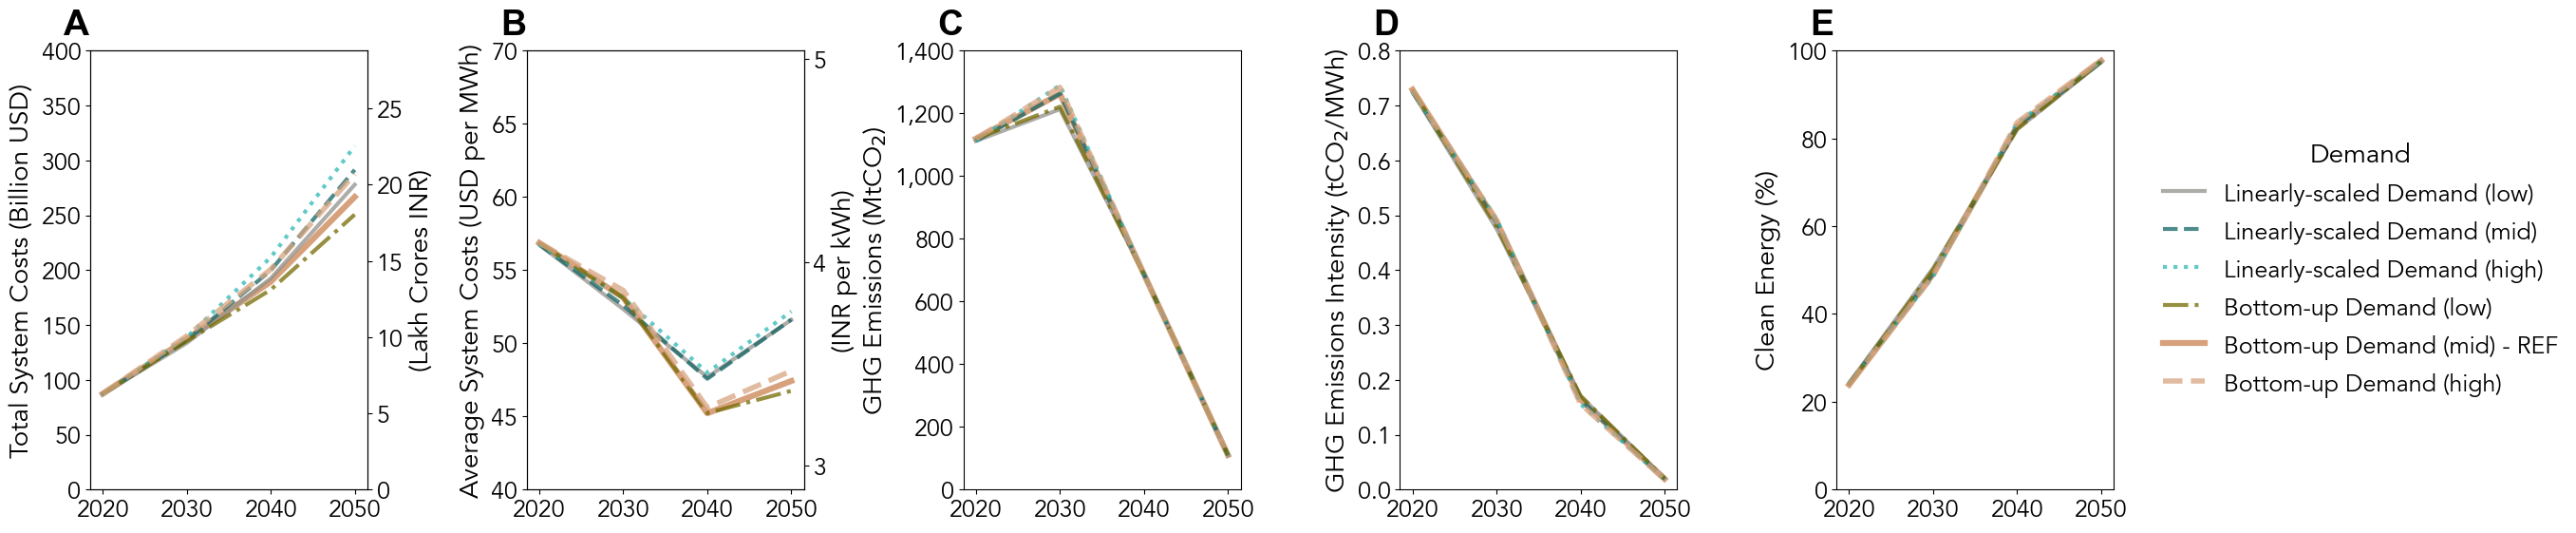

In [11]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
                              figsize     = (27.5, 6), 
                              gridspec_kw = {'wspace': .575,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize  = 27, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')
    
demands_['scen_labels']['marker'] = None

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], demands_['system_cost'], demands_['scen_labels'], 
                     y_min = 0,
                     y_max = 400,
                     legend = False)

# Plot average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'], demands_['system_cost'], demands_['demand'], demands_['scen_labels'],                  
                       y_min = 40,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], demands_['emissions'], demands_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], demands_['emissions'], demands_['scen_labels'], 
                                    y_min = 0.,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], demands_['clean_energy'], demands_['scen_labels'], 
                       legend_title = 'Demand',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/demand_profiles-summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/demand_profiles-summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [5]:
pier_ = {}
pier_['scen_labels'] = pd.read_csv(path_to_csvs + '/pier-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(pier_['scen_labels'])
cost_, demand_ = ld._load_cost(pier_['scen_labels'])
clean_ = ld._load_clean_energy(pier_['scen_labels'])

pier_['emissions'] = prc._group_emissions_by_zone(emission_, pier_['scen_labels'])
pier_['system_cost'], pier_['demand'] = prc._group_cost_by_zone(cost_, demand_, pier_['scen_labels'])
pier_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, pier_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
pier_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(pier_, path_to_output, file_name = 'pier-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES

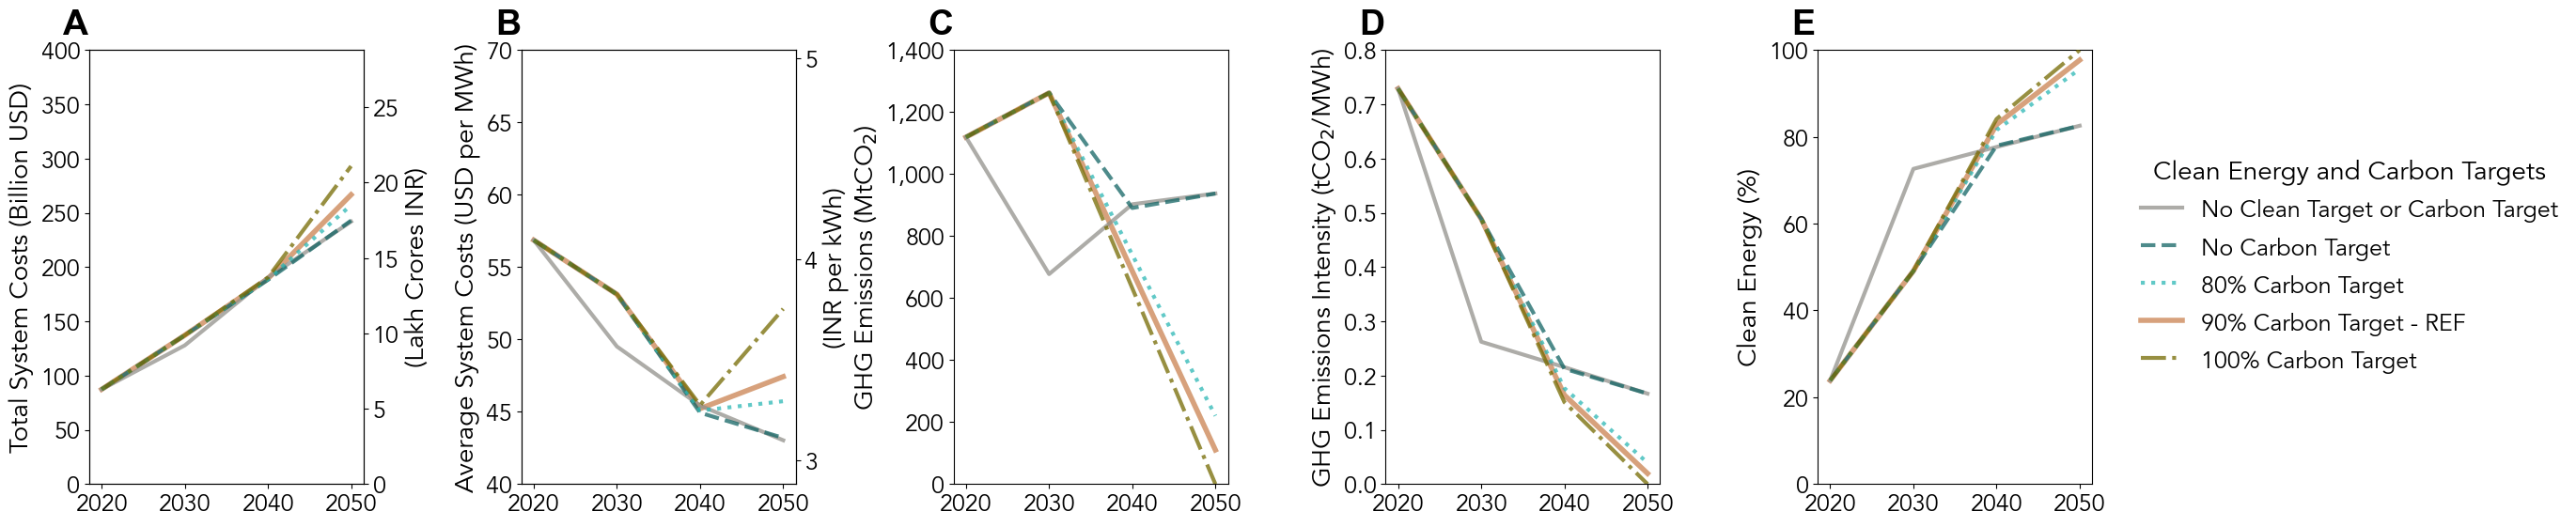

In [12]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
                              figsize = (27.5, 6), 
                              gridspec_kw = {'wspace': .575,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize = 27, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

pier_['scen_labels']['marker'] = None

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], pier_['system_cost'], pier_['scen_labels'], 
                 y_min = 0,
                 y_max = 400,
                 legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'], pier_['system_cost'], pier_['demand'], pier_['scen_labels'], 
                   y_min = 40,
                   y_max = 70,
                   legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], pier_['emissions'], pier_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], pier_['emissions'], pier_['scen_labels'], 
                                    y_min = 0,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], pier_['clean_energy'], pier_['scen_labels'], 
                       legend_title = 'Clean Energy and Carbon Targets',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/pier-summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/pier-summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [7]:
costs_ = {}
costs_['scen_labels'] = pd.read_csv(path_to_csvs + '/cost-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(costs_['scen_labels'])
cost_, demand_ = ld._load_cost(costs_['scen_labels'])
clean_ = ld._load_clean_energy(costs_['scen_labels'])

costs_['emissions'] = prc._group_emissions_by_zone(emission_, costs_['scen_labels'])
costs_['system_cost'], costs_['demand'] = prc._group_cost_by_zone(cost_, demand_, costs_['scen_labels'])
costs_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, costs_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
costs_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(costs_, path_to_output, file_name = 'cost-{}.csv')

VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/grid

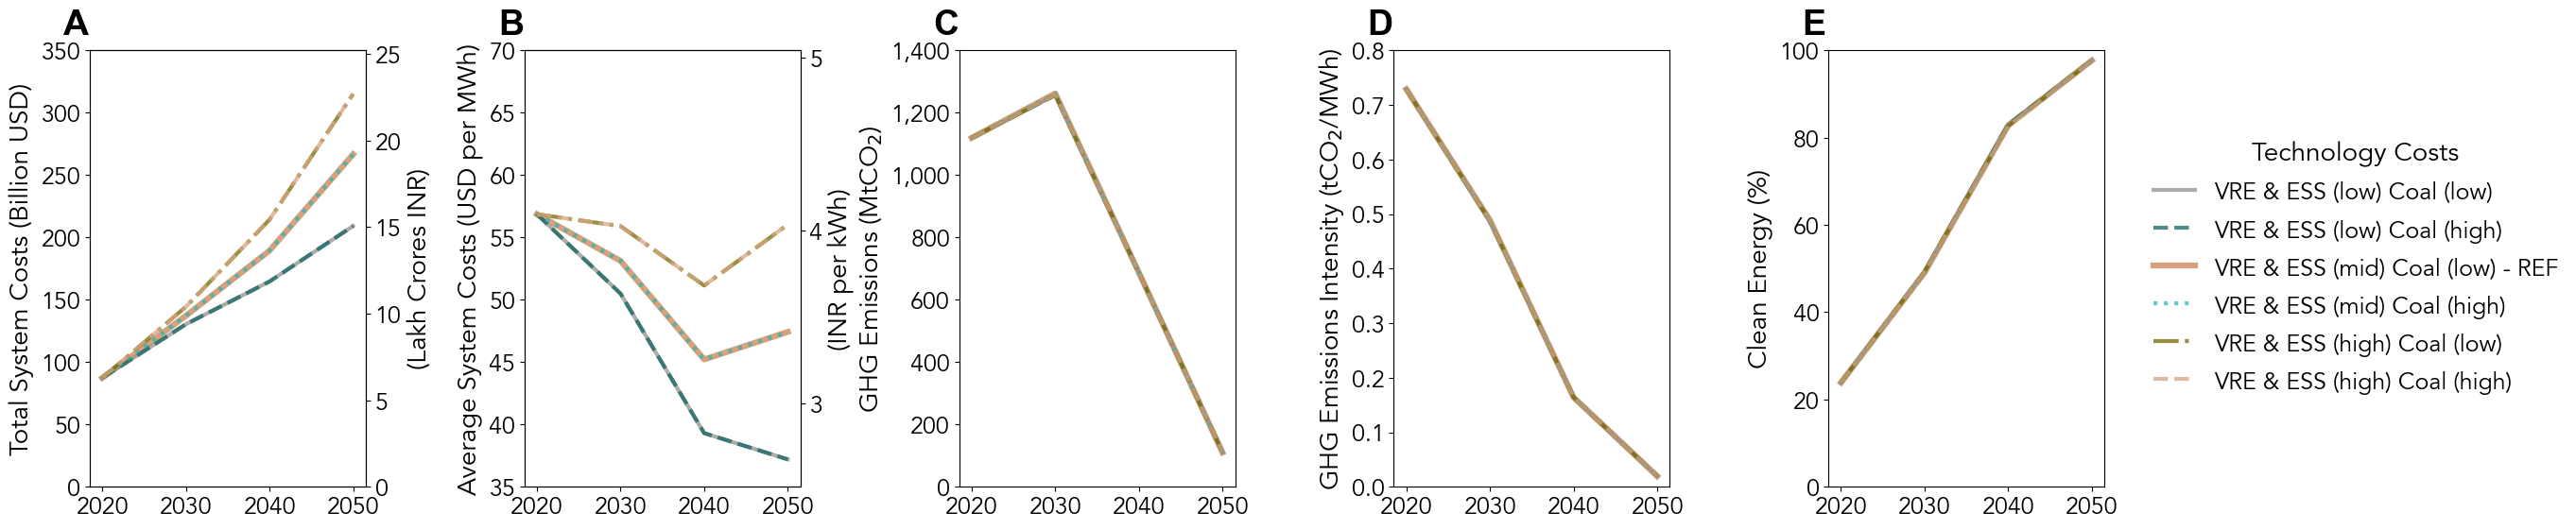

In [13]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
                              figsize = (27.5, 6), 
                              gridspec_kw = {'wspace': .575,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize = 27, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

costs_['scen_labels']['marker'] = None

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], costs_['system_cost'], costs_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'], costs_['system_cost'], costs_['demand'], costs_['scen_labels'], 
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], costs_['emissions'],  costs_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], costs_['emissions'],  costs_['scen_labels'], 
                                    y_min = 0,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], costs_['clean_energy'], costs_['scen_labels'], 
                       legend_title = 'Technology Costs',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/cost-summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/cost-summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

## Mosaic

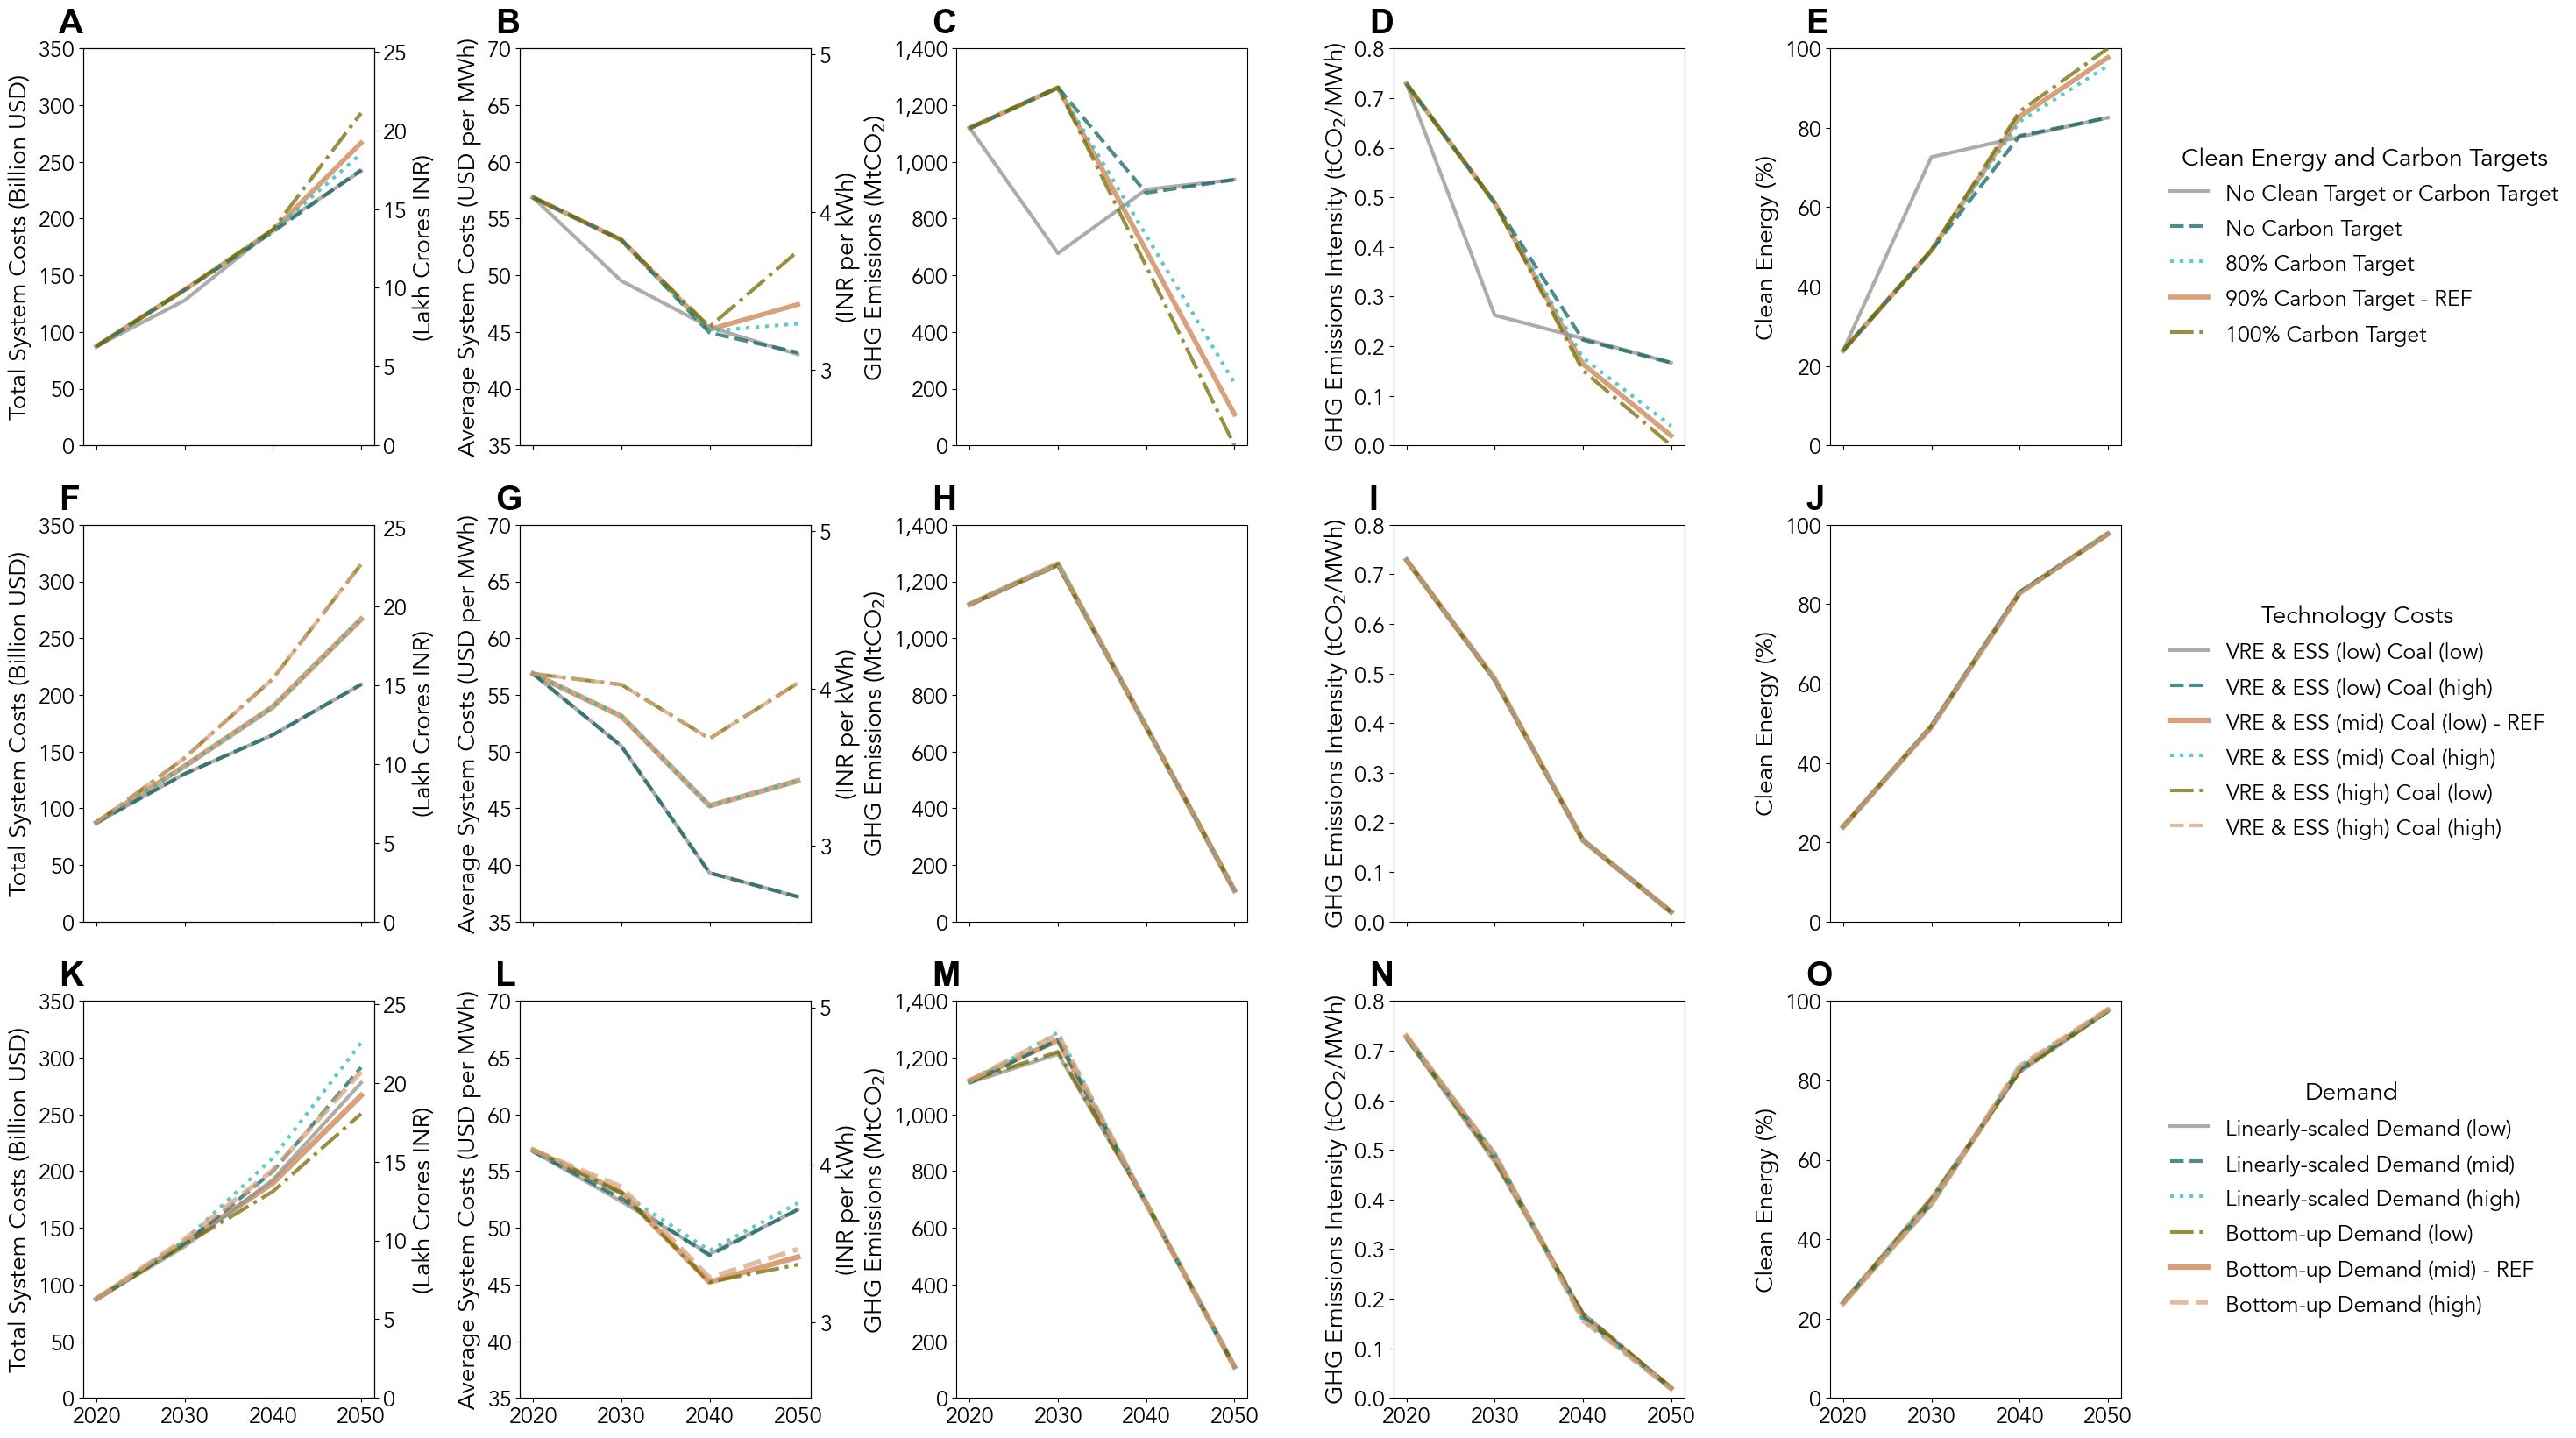

In [14]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E'],
                               ['F', 'G', 'H', 'I', 'J'],
                               ['K', 'L', 'M', 'N', 'O']], 
                              sharex = True,
                              figsize = (30, 20), 
                              gridspec_kw = {'wspace': .5,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize = 28, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], pier_['system_cost'], pier_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'], pier_['system_cost'], pier_['demand'], pier_['scen_labels'], 
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], pier_['emissions'], pier_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], pier_['emissions'], pier_['scen_labels'], 
                                    y_min = 0.,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], pier_['clean_energy'], pier_['scen_labels'], 
                       legend_title = 'Clean Energy and Carbon Targets',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['F'], costs_['system_cost'], costs_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['G'], costs_['system_cost'], costs_['demand'], costs_['scen_labels'], 
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['H'], costs_['emissions'],  costs_['scen_labels'], 
                           y_min = 0.,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['I'], costs_['emissions'],  costs_['scen_labels'], 
                                    y_min = 0.,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['J'], costs_['clean_energy'], costs_['scen_labels'], 
                       legend_title = 'Technology Costs',
                       y_min = 0,
                       y_max = 100,
                       legend = True)
    
# Plot system cost for different scenarios
viz._plot_total_cost(_ax['K'], demands_['system_cost'], demands_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['L'], demands_['system_cost'], demands_['demand'], demands_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['M'], demands_['emissions'], demands_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['N'], demands_['emissions'], demands_['scen_labels'], 
                                    y_min = 0,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['O'], demands_['clean_energy'], demands_['scen_labels'], 
                       legend_title = 'Demand',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

# Supporting Figures

In [20]:
alternative_ = {}
alternative_['scen_labels'] = pd.read_csv(path_to_csvs + '/alternative-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(alternative_['scen_labels'])
cost_, demand_ = ld._load_cost(alternative_['scen_labels'])
clean_ = ld._load_clean_energy(alternative_['scen_labels'])

alternative_['emissions'] = prc._group_emissions_by_zone(emission_, alternative_['scen_labels'])
alternative_['system_cost'], alternative_['demand'] = prc._group_cost_by_zone(cost_, demand_, alternative_['scen_labels'])
alternative_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, alternative_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
alternative_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(alternative_, path_to_output, file_name = 'alternative-{}.csv')

VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_N_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2PSHN_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/

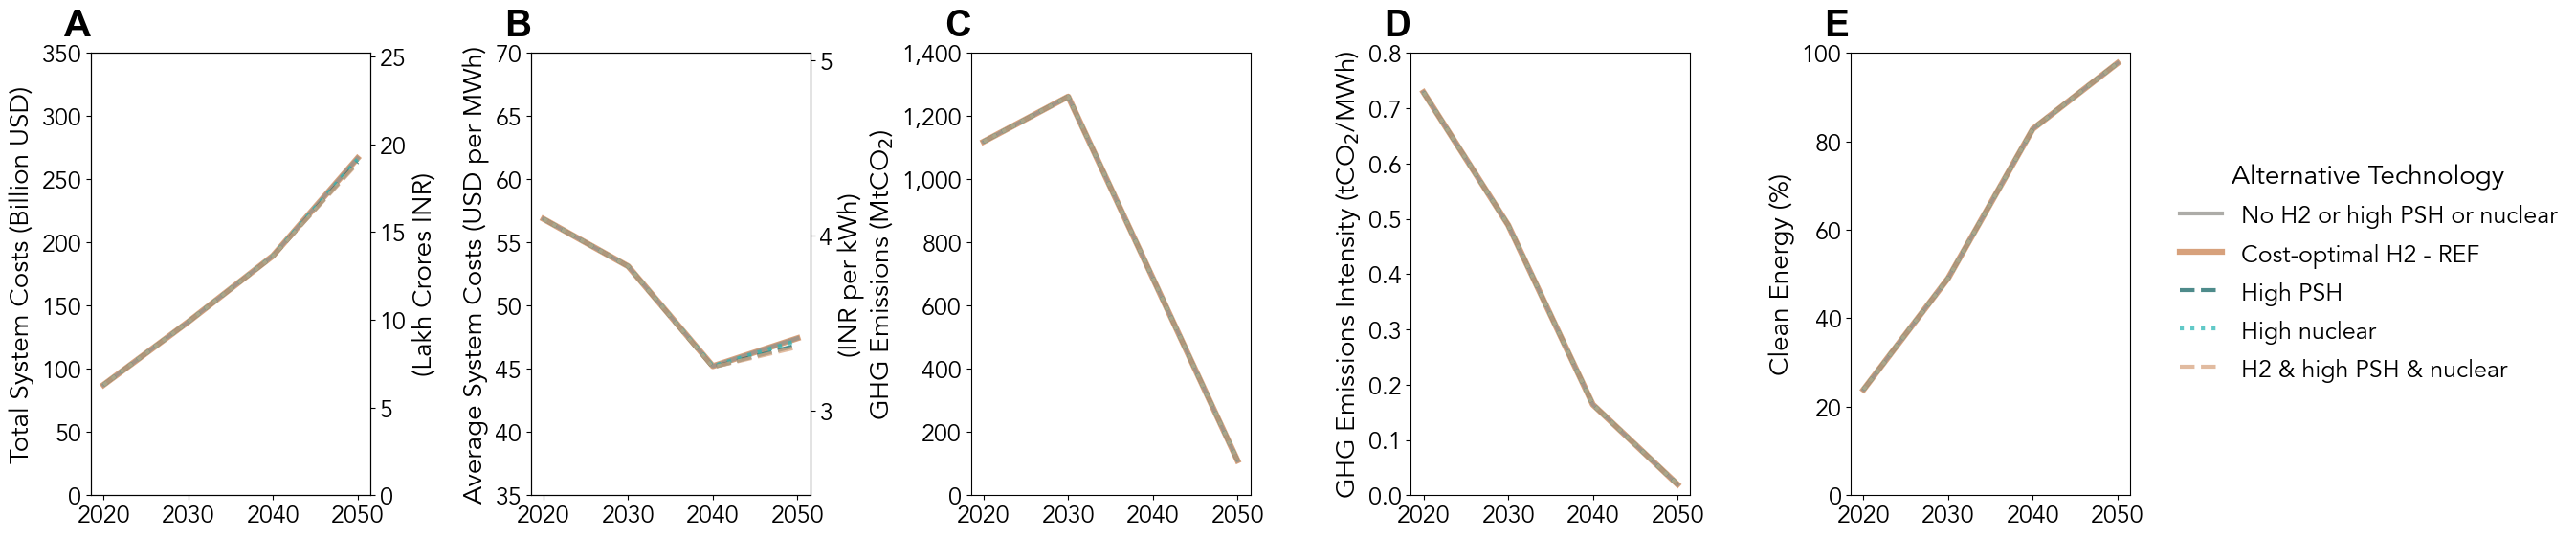

In [21]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
                              figsize = (27.5, 6), 
                              gridspec_kw = {'wspace': .575,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize = 28, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')
    
alternative_['scen_labels']['marker'] = None

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], alternative_['system_cost'], alternative_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)
 
# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'], alternative_['system_cost'], alternative_['demand'], alternative_['scen_labels'], 
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], alternative_['emissions'],  alternative_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], alternative_['emissions'], alternative_['scen_labels'], 
                                    y_min = 0.,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], alternative_['clean_energy'], alternative_['scen_labels'], 
                       legend_title = 'Alternative Technology',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/SI-alternative-summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-alternative-summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [18]:
iced_ = {}
iced_['scen_labels'] = pd.read_csv(path_to_csvs + '/iced-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(iced_['scen_labels'])
cost_, demand_ = ld._load_cost(iced_['scen_labels'])
clean_ = ld._load_clean_energy(iced_['scen_labels'])

iced_['emissions'] = prc._group_emissions_by_zone(emission_, iced_['scen_labels'])
iced_['system_cost'], iced_['demand'] = prc._group_cost_by_zone(cost_, demand_, iced_['scen_labels'])
iced_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, iced_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
iced_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(iced_, path_to_output, file_name = 'iced-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_R

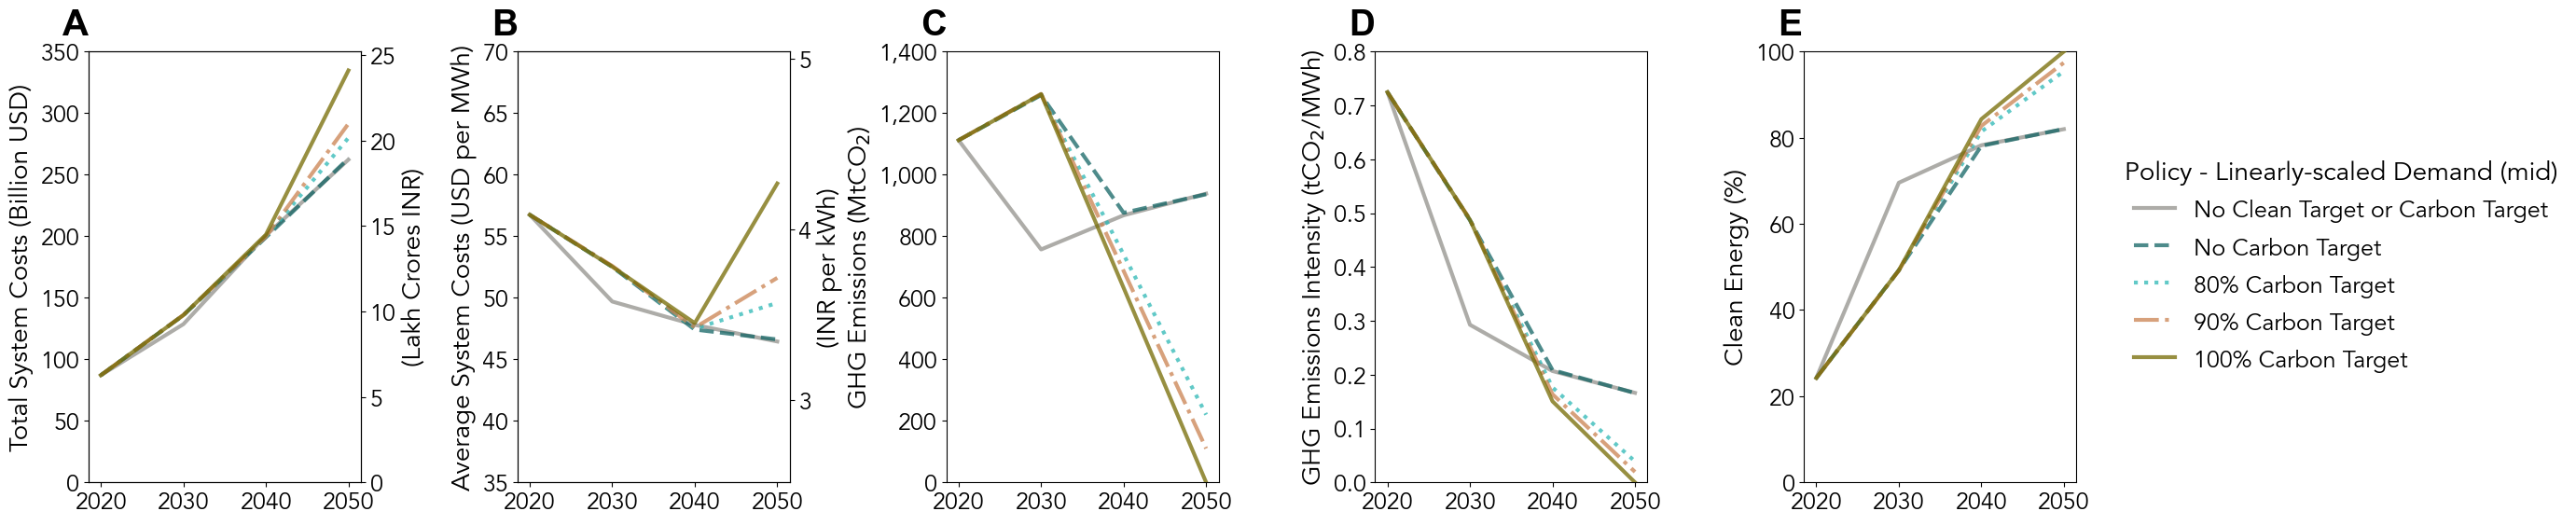

In [19]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E']], 
                              figsize = (27.5, 6), 
                              gridspec_kw = {'wspace': .575,
                                             'width_ratios': [1, 1, 1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
            fontsize = 28, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')
    
iced_['scen_labels']['marker'] = None

# Plot system cost for different scenarios
viz._plot_total_cost(_ax['A'], iced_['system_cost'], iced_['scen_labels'], 
                     y_min = 0,
                     y_max = 350,
                     legend = False)

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['B'],  iced_['system_cost'], iced_['demand'], iced_['scen_labels'], 
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['C'], iced_['emissions'], iced_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions_intesity(_ax['D'], iced_['emissions'], iced_['scen_labels'], 
                                    y_min = 0.,
                                    y_max = 0.8,
                                    legend = False)

# Plot renewable portfolio for different scenarios
viz._plot_clean_energy(_ax['E'], iced_['clean_energy'], iced_['scen_labels'], 
                       legend_title = 'Policy - Linearly-scaled Demand (mid)',
                       y_min = 0,
                       y_max = 100,
                       legend = True)

plt.savefig(path_to_images + '/SI-iced-summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-iced-summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()